# VAYU — Data Preparation Pipeline
## Step 6: Dimensionality Reduction Dataset (PCA, t-SNE, SVD)

**Prerequisite:** Run `vayu_step2_cleaning.ipynb` first.

---

### What This Step Builds

**Techniques:** PCA, t-SNE, SVD *(Lectures 46–54)*

**Goal:** Reduce the 6-dimensional pollutant feature space to 2–3 dimensions for visualization and feature compression. Answer questions like:
- Do cities naturally separate in pollutant space?
- Which pollutants carry the most variance?
- Can we represent pollution patterns with fewer numbers without losing much information?

### Three Techniques, Three Purposes

| Technique | Type | What It Does | When to Use |
|---|---|---|---|
| **PCA** | Linear | Finds directions of maximum variance. Components are linear combinations of original features. | When you want to understand which pollutants co-vary, or reduce features before regression. |
| **t-SNE** | Non-linear | Preserves local neighborhood structure. Points that were close in 6D stay close in 2D. | When you want to visualize natural clusters or groups in the data. |
| **SVD** | Linear | Matrix factorization — decomposes the data matrix into singular values. Related to PCA but operates on the raw matrix. | When you want to understand the rank/compressibility of the data matrix. |

### Data Requirements for Dimensionality Reduction

| Requirement | Why |
|---|---|
| Purely numeric matrix | No text, no categories — only the 6 pollutant concentrations |
| No missing values | PCA/SVD cannot handle NaN in the matrix |
| StandardScaler normalized | PCA is variance-based — a feature with range 0–1000 would dominate one with range 0–50 |
| t-SNE on a sample | t-SNE is O(n²) in memory — running on 842k rows is not feasible. We sample 15,000 rows. |

### Steps in This Notebook
1. Load master cleaned file
2. Extract the pure pollutant matrix
3. Standardize with StandardScaler
4. PCA — explained variance, component loadings, 2D scatter
5. SVD — singular value spectrum, explained variance
6. t-SNE — 2D scatter on a sample, colored by city and AQI category
7. Save dimensionality datasets

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 30)

OUTPUT_DIR = './data/cleaned/04_dimensionality'
SHARED_DIR = './data/cleaned/04_shared'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TSNE_SAMPLE_SIZE = 15000   # t-SNE is O(n^2) — sample for speed
RANDOM_STATE     = 42

print('Setup complete.')

Setup complete.


---
## Section 1 — Load Master Cleaned File

In [2]:
parquet_path = os.path.join(SHARED_DIR, 'master_cleaned.parquet')
csv_path     = os.path.join(SHARED_DIR, 'master_cleaned.csv')

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print(f'Loaded from parquet: {parquet_path}')
else:
    df = pd.read_csv(csv_path, low_memory=False)
    print(f'Loaded from CSV: {csv_path}')

print(f'Shape : {df.shape[0]:,} rows x {df.shape[1]} columns')

# Auto-detect columns
POLLUTANT_KEYWORDS = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3', 'ozone', 'nh3']
EXCLUDE_KEYWORDS   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                      'wind', 'rain', 'solar', 'visibility', 'dew', 'uv']

pollutant_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLLUTANT_KEYWORDS)
    and not any(ex in c.lower() for ex in EXCLUDE_KEYWORDS)
]
city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
cat_col  = next((c for c in df.columns
                 if 'category' in c.lower() or 'bucket' in c.lower()), None)

print(f'Pollutant cols : {pollutant_cols}')
print(f'City col       : {city_col}')
print(f'Category col   : {cat_col}')

Loaded from CSV: ./data/cleaned/05_shared/master_cleaned.csv
Shape : 842,160 rows x 35 columns
Pollutant cols : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
City col       : city
Category col   : aqi_category


---
## Section 2 — Extract Pure Pollutant Matrix

### Why Only the 6 Pollutant Columns?

PCA finds directions of maximum variance in your feature space. If we include time features (month, hour), the principal components would partially reflect temporal patterns — e.g., PC1 might separate morning from afternoon readings rather than separating high-PM2.5 from high-O3 signatures.

We want PCA to reveal **pollutant co-occurrence patterns** — which pollutants tend to be elevated together. Including non-pollutant features would pollute (pun intended) those patterns.

After extracting the matrix we drop all rows with any NaN — PCA and SVD require a complete matrix with no missing entries.

In [3]:
# Build the pollutant matrix with optional metadata columns
meta_cols  = [c for c in [city_col, cat_col] if c is not None]
keep_cols  = meta_cols + pollutant_cols
df_dim     = df[keep_cols].dropna(subset=pollutant_cols).reset_index(drop=True)

print(f'Rows with complete pollutant data : {len(df_dim):,}')
print(f'Rows dropped (any pollutant NaN)  : {len(df) - len(df_dim):,}')
print(f'Pollutant matrix shape            : {df_dim[pollutant_cols].shape}')

print('\nPollutant statistics (raw, before scaling):')
display(df_dim[pollutant_cols].describe().round(2))

Rows with complete pollutant data : 842,160
Rows dropped (any pollutant NaN)  : 0
Pollutant matrix shape            : (842160, 6)

Pollutant statistics (raw, before scaling):


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
count,842160.00,842160.00,842160.00,842160.00,842160.00,842160.00
mean,34.55,54.01,444.93,15.99,13.39,80.19
std,29.65,54.23,377.01,19.90,18.92,44.76
min,1.90,2.30,96.00,0.00,0.20,0.00
25%,14.70,21.50,235.00,3.70,2.80,47.00
50%,25.90,39.00,333.00,9.00,6.90,73.00
75%,44.20,66.40,508.00,19.90,15.80,108.00
max,183.50,420.00,2903.00,122.10,134.20,228.00


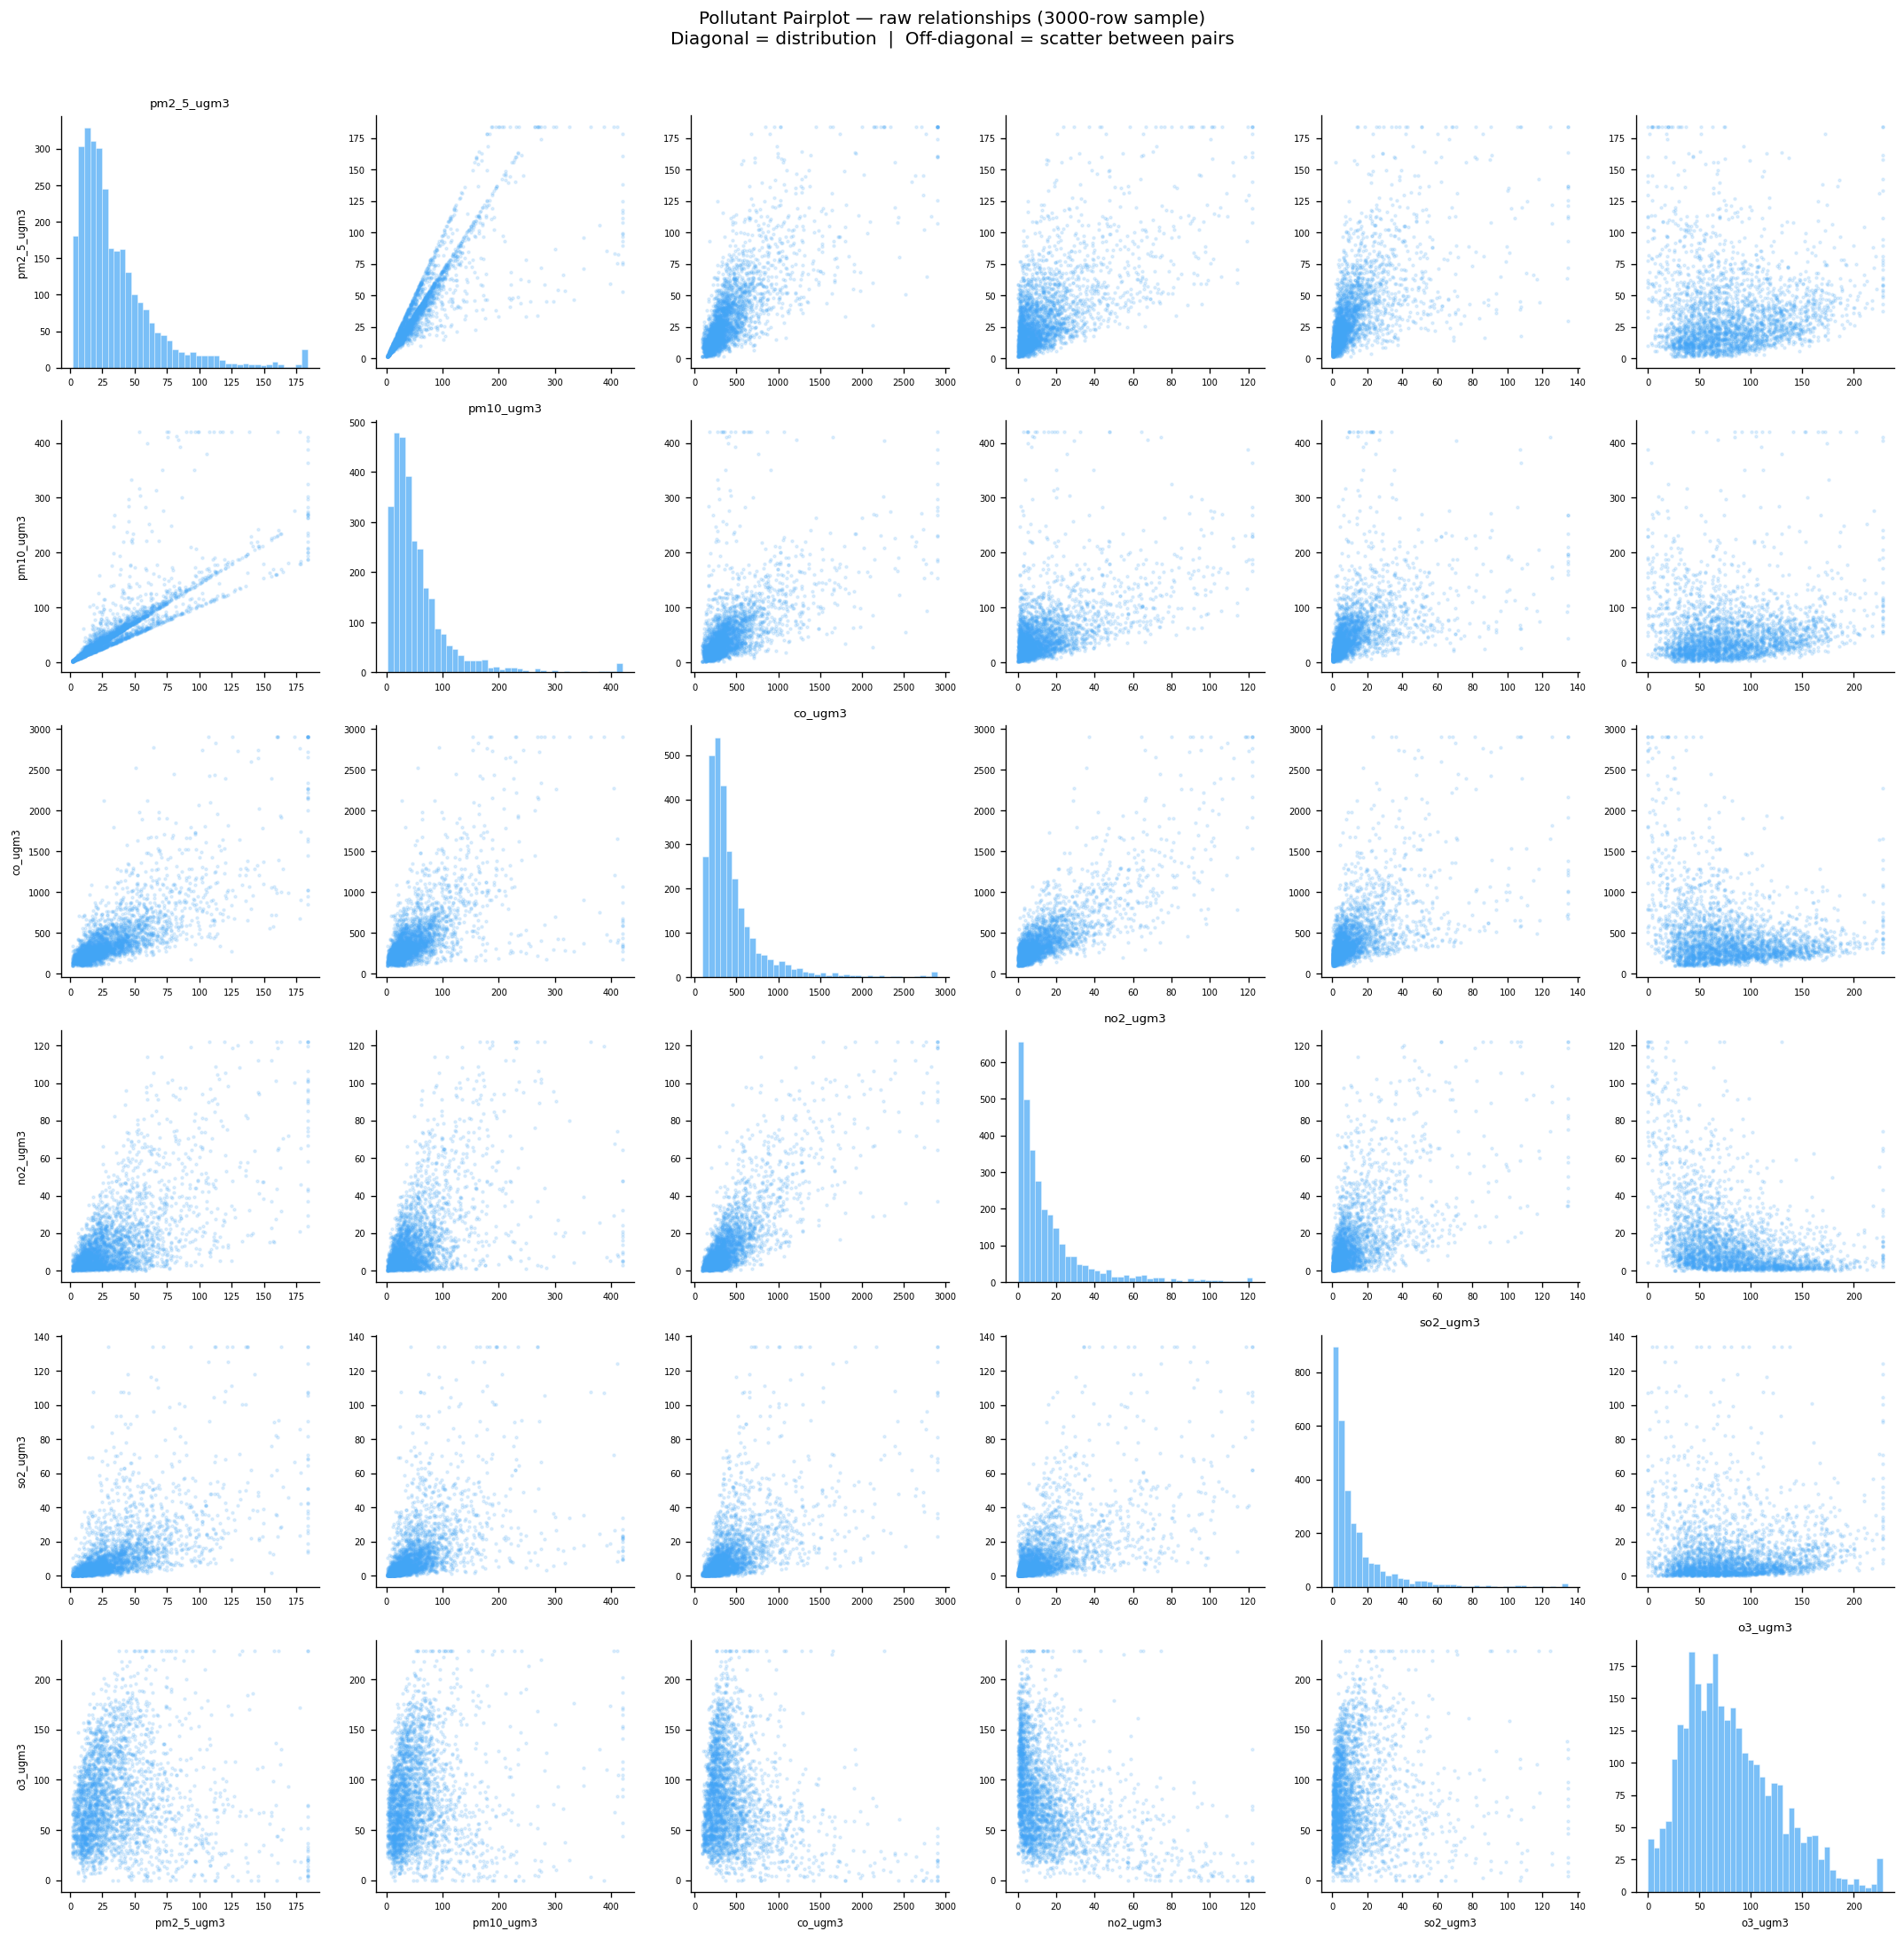

In [4]:
# ── Pairplot — pollutant relationships before PCA ─────────────────────────
# Sample 3000 rows for speed
sample_plot = df_dim[pollutant_cols].sample(min(3000, len(df_dim)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(len(pollutant_cols), len(pollutant_cols),
                          figsize=(3 * len(pollutant_cols), 3 * len(pollutant_cols)))

for i, col_i in enumerate(pollutant_cols):
    for j, col_j in enumerate(pollutant_cols):
        ax = axes[i][j]
        if i == j:
            ax.hist(sample_plot[col_i].dropna(), bins=40,
                    color='#42A5F5', alpha=0.7, edgecolor='white', linewidth=0.3)
            ax.set_title(col_i, fontsize=8)
        else:
            ax.scatter(sample_plot[col_j], sample_plot[col_i],
                       alpha=0.15, s=3, color='#42A5F5')
        if i == len(pollutant_cols) - 1: ax.set_xlabel(col_j, fontsize=7)
        if j == 0:                       ax.set_ylabel(col_i, fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle('Pollutant Pairplot — raw relationships (3000-row sample)\n'
             'Diagonal = distribution  |  Off-diagonal = scatter between pairs',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 3 — StandardScaler Normalization

### Why Scaling Is Mandatory Before PCA

PCA finds the directions of **maximum variance**. Variance is computed in the units of each feature. If PM2.5 ranges 0–1000 µg/m³ and O3 ranges 0–300 µg/m³, PM2.5 will automatically have higher variance and PC1 will be almost entirely a PM2.5 axis — the other pollutants get suppressed.

After StandardScaler, every pollutant has mean=0 and std=1. PCA now finds directions that capture co-variance patterns across all pollutants equally.

Scaling complete.
Scaled matrix shape : (842160, 6)
Mean per feature (should be ~0)  : [ 0. -0. -0. -0.  0.  0.]
Std  per feature (should be ~1)  : [1. 1. 1. 1. 1. 1.]


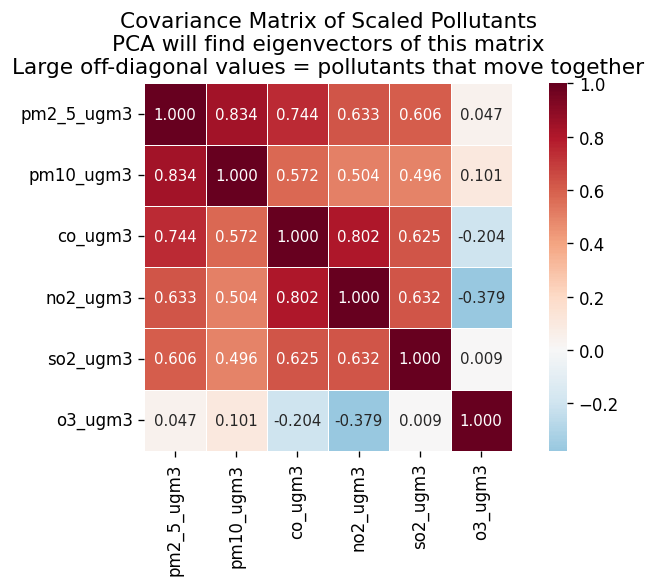

In [5]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_dim[pollutant_cols])
X_raw    = df_dim[pollutant_cols].values

print('Scaling complete.')
print(f'Scaled matrix shape : {X_scaled.shape}')
print(f'Mean per feature (should be ~0)  : {X_scaled.mean(axis=0).round(4)}')
print(f'Std  per feature (should be ~1)  : {X_scaled.std(axis=0).round(4)}')

# ── Covariance matrix of scaled data ─────────────────────────────────────
cov_mat  = np.cov(X_scaled.T)
cov_df   = pd.DataFrame(cov_mat, index=pollutant_cols, columns=pollutant_cols)

fig, ax  = plt.subplots(figsize=(max(7, len(pollutant_cols)), max(5, len(pollutant_cols)-1)))
sns.heatmap(cov_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Covariance Matrix of Scaled Pollutants\n'
             'PCA will find eigenvectors of this matrix\n'
             'Large off-diagonal values = pollutants that move together')
plt.tight_layout()
plt.show()

---
## Section 4 — PCA (Principal Component Analysis)

### What PCA Actually Does

PCA finds a new coordinate system where:
- **PC1** points in the direction of maximum variance across all rows
- **PC2** points in the direction of maximum variance that is perpendicular to PC1
- And so on...

Each PC is a **linear combination** of the original features. The weights are called **loadings**. A loading of 0.8 on PM2.5 in PC1 means PM2.5 strongly contributes to PC1 — rows with high PM2.5 will have large positive PC1 values.

The **explained variance ratio** tells you what % of total variance each PC captures. If PC1 + PC2 together explain 80%, then 2D is a good representation of the 6D data.

PCA Explained Variance:
  PC1   60.06%  cumulative  60.06%  ############################################################
  PC2   20.46%  cumulative  80.53%  ####################
  PC3    9.23%  cumulative  89.76%  #########
  PC4    5.26%  cumulative  95.01%  #####
  PC5    2.99%  cumulative  98.00%  ##
  PC6    2.00%  cumulative 100.00%  #

Components needed for 90% variance: 4
Components needed for 95% variance: 4


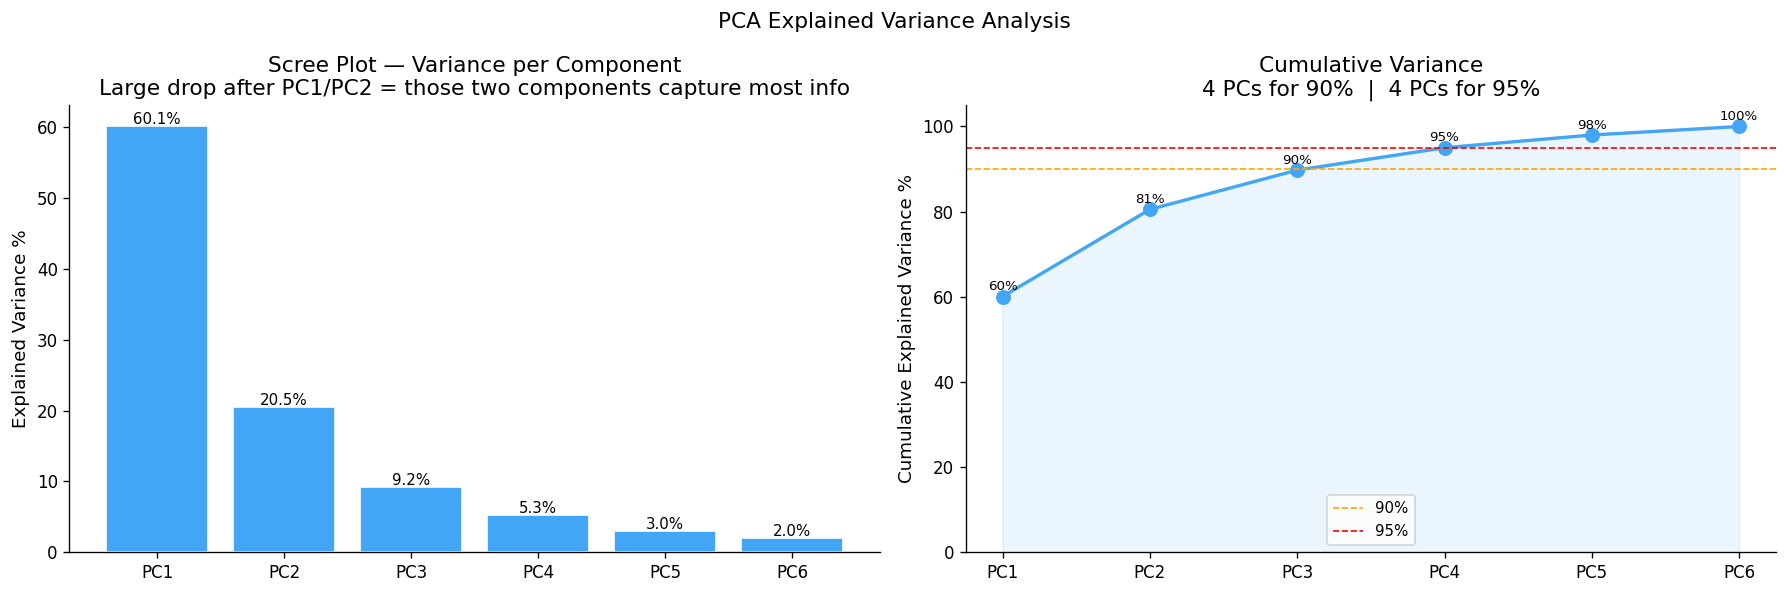

In [6]:
# Full PCA — all components
n_components = len(pollutant_cols)
pca_full     = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca_full   = pca_full.fit_transform(X_scaled)

exp_var      = pca_full.explained_variance_ratio_
cum_var      = np.cumsum(exp_var)

print('PCA Explained Variance:')
for i, (ev, cv) in enumerate(zip(exp_var, cum_var), 1):
    bar = '#' * int(ev * 100)
    print(f'  PC{i}  {ev*100:>6.2f}%  cumulative {cv*100:>6.2f}%  {bar}')

# How many components needed to reach 90% variance?
n_for_90 = np.argmax(cum_var >= 0.90) + 1
n_for_95 = np.argmax(cum_var >= 0.95) + 1
print(f'\nComponents needed for 90% variance: {n_for_90}')
print(f'Components needed for 95% variance: {n_for_95}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
pc_labels = [f'PC{i+1}' for i in range(n_components)]
axes[0].bar(pc_labels, exp_var * 100, color='#42A5F5', edgecolor='white')
axes[0].set_ylabel('Explained Variance %')
axes[0].set_title('Scree Plot — Variance per Component\n'
                  'Large drop after PC1/PC2 = those two components capture most info')
for i, v in enumerate(exp_var):
    axes[0].text(i, v * 100 + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)

# Cumulative variance
axes[1].plot(pc_labels, cum_var * 100, 'o-', color='#42A5F5', linewidth=2, markersize=8)
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(95, color='red',    linestyle='--', linewidth=1, label='95%')
axes[1].fill_between(range(n_components), cum_var * 100, alpha=0.1, color='#42A5F5')
axes[1].set_ylabel('Cumulative Explained Variance %')
axes[1].set_title(f'Cumulative Variance\n'
                  f'{n_for_90} PCs for 90%  |  {n_for_95} PCs for 95%')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)
for i, (label, cv) in enumerate(zip(pc_labels, cum_var)):
    axes[1].text(i, cv * 100 + 1.5, f'{cv*100:.0f}%', ha='center', fontsize=8)

plt.suptitle('PCA Explained Variance Analysis', fontsize=13)
plt.tight_layout()
plt.show()

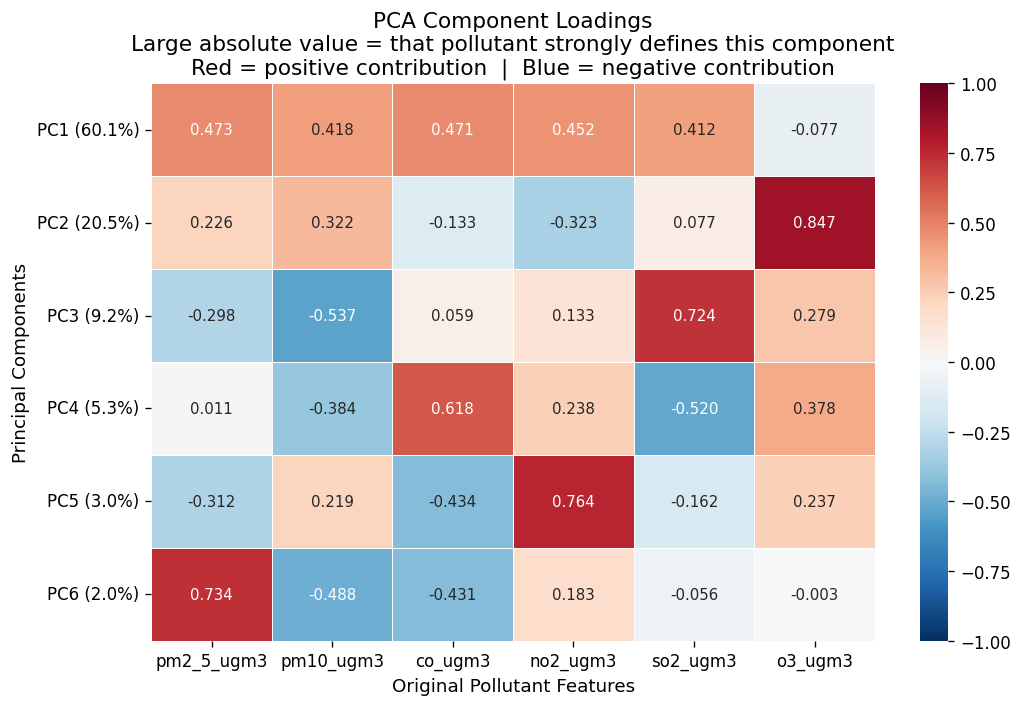

Interpretation guide:
  PC1: driven by ['pm2_5_ugm3', 'co_ugm3'] (positive) and ['o3_ugm3', 'so2_ugm3'] (negative)
  PC2: driven by ['o3_ugm3', 'pm10_ugm3'] (positive) and ['no2_ugm3', 'co_ugm3'] (negative)
  PC3: driven by ['so2_ugm3', 'o3_ugm3'] (positive) and ['pm10_ugm3', 'pm2_5_ugm3'] (negative)


In [7]:
# ── Component loadings heatmap ─────────────────────────────────────────────
loadings_df = pd.DataFrame(
    pca_full.components_,
    index   = [f'PC{i+1} ({exp_var[i]*100:.1f}%)' for i in range(n_components)],
    columns = pollutant_cols
)

fig, ax = plt.subplots(figsize=(max(8, len(pollutant_cols)*1.5),
                                max(5, n_components)))
sns.heatmap(
    loadings_df, annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('PCA Component Loadings\n'
             'Large absolute value = that pollutant strongly defines this component\n'
             'Red = positive contribution  |  Blue = negative contribution')
ax.set_xlabel('Original Pollutant Features')
ax.set_ylabel('Principal Components')
plt.tight_layout()
plt.show()

print('Interpretation guide:')
for i in range(min(3, n_components)):
    top_pos = loadings_df.iloc[i].nlargest(2).index.tolist()
    top_neg = loadings_df.iloc[i].nsmallest(2).index.tolist()
    print(f'  PC{i+1}: driven by {top_pos} (positive) and {top_neg} (negative)')

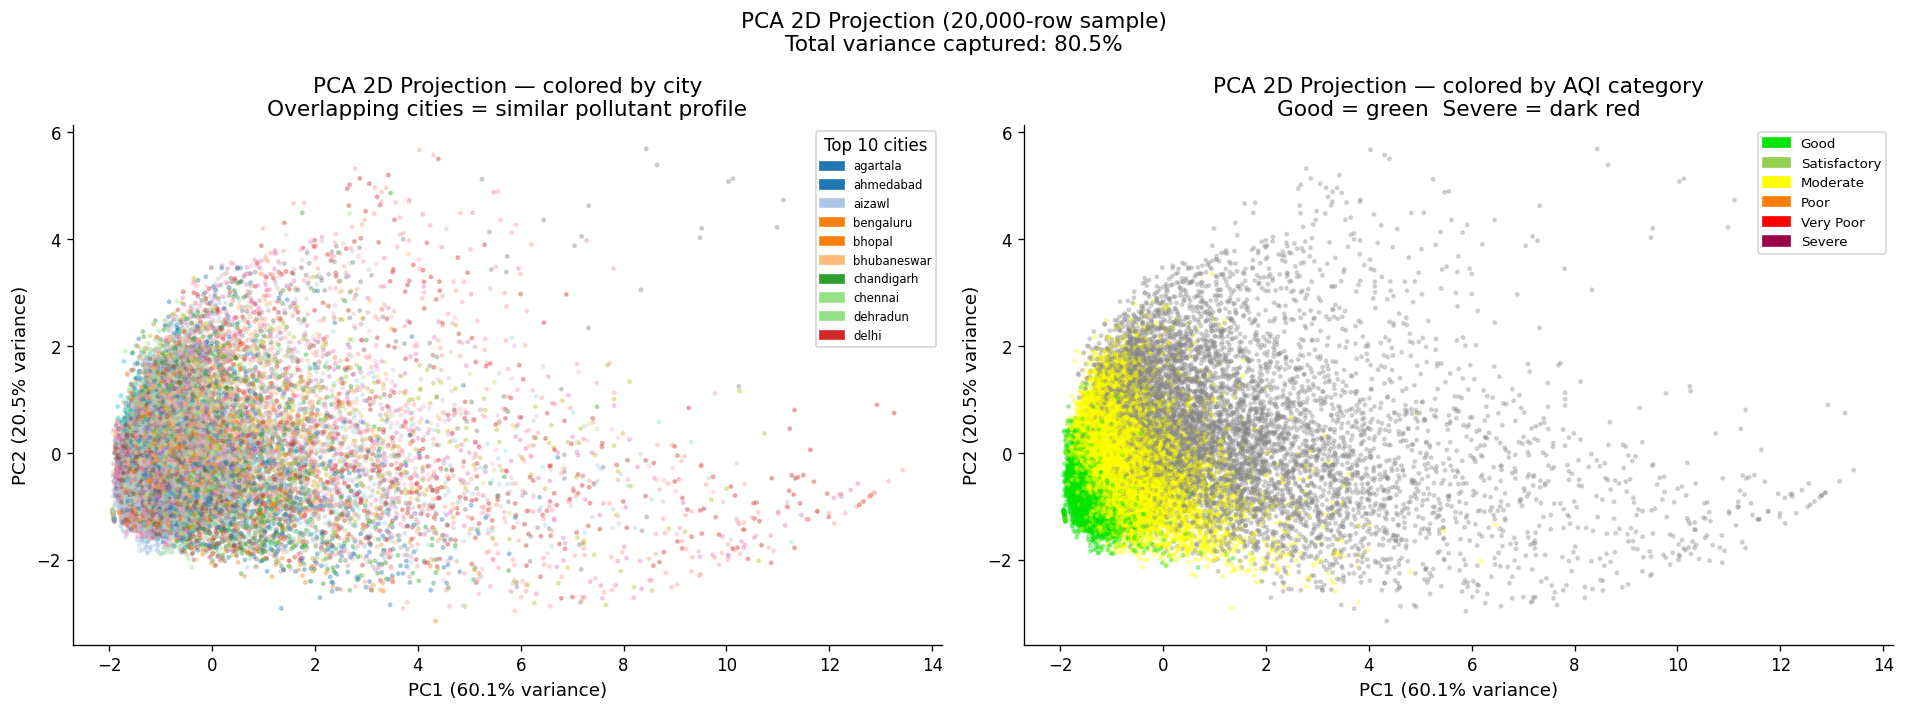

In [8]:
# ── PCA 2D scatter ─────────────────────────────────────────────────────────
pca_2d   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)
ev2      = pca_2d.explained_variance_ratio_

# Sample for plotting (too many points = unreadable)
plot_n   = min(20000, len(X_pca_2d))
plot_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pca_2d), plot_n, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by city (if available)
if city_col and city_col in df_dim.columns:
    cities   = df_dim[city_col].iloc[plot_idx].values
    uniq_c   = np.unique(cities)
    cmap_c   = plt.cm.tab20(np.linspace(0, 1, len(uniq_c)))
    city_color_map = {city: cmap_c[i] for i, city in enumerate(uniq_c)}
    point_colors   = [city_color_map[c] for c in cities]
    axes[0].scatter(X_pca_2d[plot_idx, 0], X_pca_2d[plot_idx, 1],
                    c=point_colors, alpha=0.3, s=4)
    # Legend for top 10 cities only
    top_cities = df_dim[city_col].value_counts().head(10).index.tolist()
    handles = [mpatches.Patch(color=city_color_map[c], label=c)
               for c in top_cities if c in city_color_map]
    axes[0].legend(handles=handles, fontsize=7, loc='upper right',
                   title='Top 10 cities')
else:
    axes[0].scatter(X_pca_2d[plot_idx, 0], X_pca_2d[plot_idx, 1],
                    alpha=0.2, s=4, color='#42A5F5')

axes[0].set_xlabel(f'PC1 ({ev2[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({ev2[1]*100:.1f}% variance)')
axes[0].set_title('PCA 2D Projection — colored by city\n'
                  'Overlapping cities = similar pollutant profile')

# Right: colored by AQI category (if available)
CAT_ORDER  = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLORS = {'Good':'#00E400','Satisfactory':'#92D050','Moderate':'#FFFF00',
              'Poor':'#FF7E00','Very Poor':'#FF0000','Severe':'#99004C'}

if cat_col and cat_col in df_dim.columns:
    cats   = df_dim[cat_col].iloc[plot_idx].astype(str).str.strip().str.title()
    colors_cat = [CAT_COLORS.get(c, '#888888') for c in cats]
    axes[1].scatter(X_pca_2d[plot_idx, 0], X_pca_2d[plot_idx, 1],
                    c=colors_cat, alpha=0.3, s=4)
    handles_cat = [mpatches.Patch(color=CAT_COLORS[c], label=c)
                   for c in CAT_ORDER if c in CAT_COLORS]
    axes[1].legend(handles=handles_cat, fontsize=8, loc='upper right')
else:
    axes[1].scatter(X_pca_2d[plot_idx, 0], X_pca_2d[plot_idx, 1],
                    alpha=0.2, s=4, color='#EF5350')

axes[1].set_xlabel(f'PC1 ({ev2[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({ev2[1]*100:.1f}% variance)')
axes[1].set_title('PCA 2D Projection — colored by AQI category\n'
                  'Good = green  Severe = dark red')

plt.suptitle(f'PCA 2D Projection ({plot_n:,}-row sample)\n'
             f'Total variance captured: {(ev2[0]+ev2[1])*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — SVD (Singular Value Decomposition)

### What SVD Does and How It Relates to PCA

SVD decomposes the data matrix X into three matrices: `X = U × Σ × Vᵀ`
- **U** — left singular vectors (how each row projects onto each component)
- **Σ** — singular values (a diagonal matrix of scaling factors)
- **Vᵀ** — right singular vectors (same as PCA loadings when data is scaled)

The **singular values** (diagonal of Σ) tell us how much information each component captures. Large singular values = important components. Near-zero singular values = redundant dimensions.

The ratio of each singular value squared to the total sum is equivalent to the PCA explained variance ratio. SVD is actually how sklearn computes PCA internally — PCA is SVD applied to the covariance matrix.

SVD Results:
  Singular values : [1742.12 1016.9   682.84  515.45  388.45  317.89]

  Component 1: singular_value= 1742.12  var=60.06%  cumvar=60.06%
  Component 2: singular_value= 1016.90  var=20.46%  cumvar=80.53%
  Component 3: singular_value=  682.84  var=9.23%  cumvar=89.76%
  Component 4: singular_value=  515.45  var=5.26%  cumvar=95.01%
  Component 5: singular_value=  388.45  var=2.99%  cumvar=98.00%
  Component 6: singular_value=  317.89  var=2.00%  cumvar=100.00%


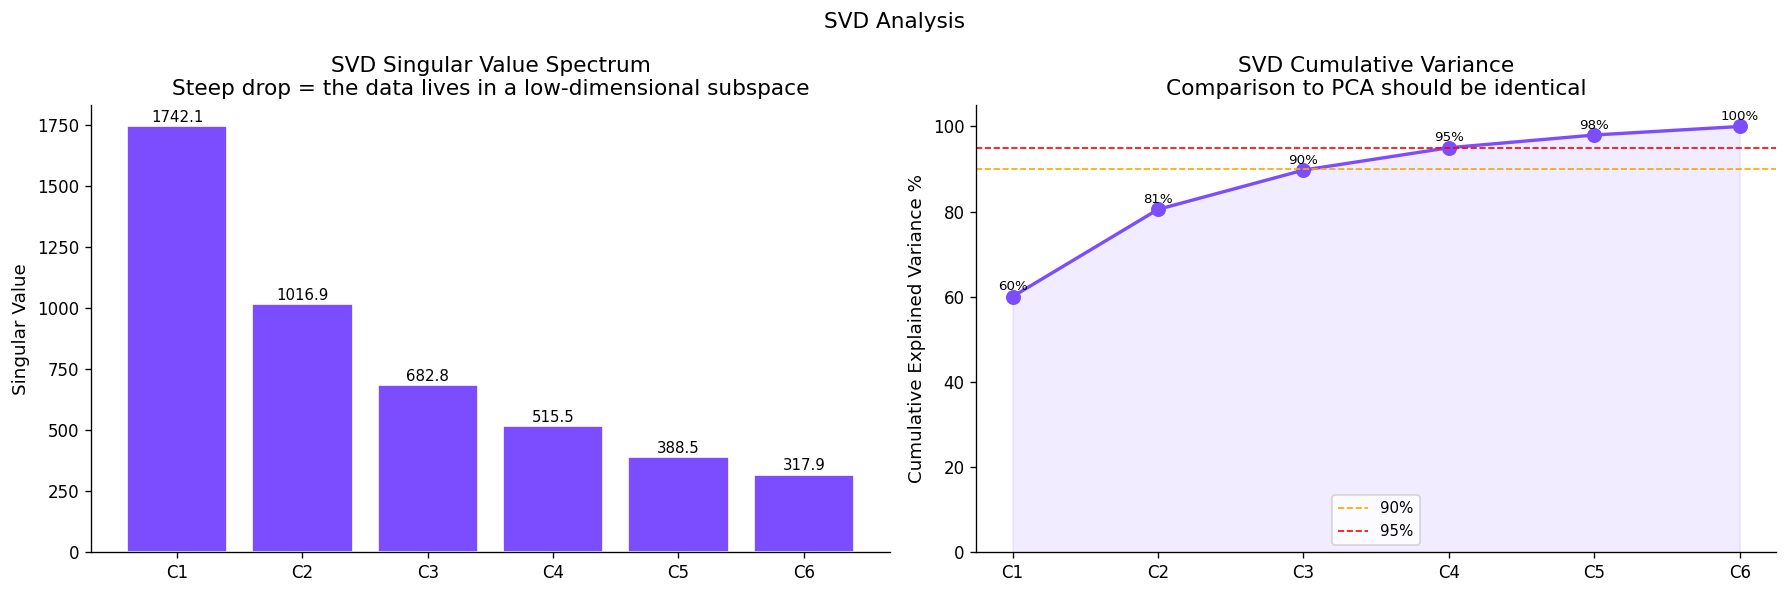


Effective rank of pollutant matrix: 4 
(meaning the 6 pollutants can be well-described using only 4 dimensions)


In [9]:
# TruncatedSVD is memory-efficient for large matrices
n_svd = len(pollutant_cols)
svd   = TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)
svd.fit(X_scaled)

singular_values = svd.singular_values_
svd_exp_var     = svd.explained_variance_ratio_
svd_cum_var     = np.cumsum(svd_exp_var)

print('SVD Results:')
print(f'  Singular values : {singular_values.round(2)}')
print()
for i, (sv, ev, cv) in enumerate(zip(singular_values, svd_exp_var, svd_cum_var), 1):
    print(f'  Component {i}: singular_value={sv:>8.2f}  var={ev*100:.2f}%  cumvar={cv*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Singular value spectrum
comp_labels = [f'C{i+1}' for i in range(n_svd)]
axes[0].bar(comp_labels, singular_values, color='#7C4DFF', edgecolor='white')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('SVD Singular Value Spectrum\n'
                  'Steep drop = the data lives in a low-dimensional subspace')
for i, sv in enumerate(singular_values):
    axes[0].text(i, sv + singular_values.max() * 0.01,
                 f'{sv:.1f}', ha='center', fontsize=9)

# Cumulative variance
axes[1].plot(comp_labels, svd_cum_var * 100, 'o-',
             color='#7C4DFF', linewidth=2, markersize=8)
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(95, color='red',    linestyle='--', linewidth=1, label='95%')
axes[1].fill_between(range(n_svd), svd_cum_var * 100, alpha=0.1, color='#7C4DFF')
axes[1].set_ylabel('Cumulative Explained Variance %')
axes[1].set_title('SVD Cumulative Variance\nComparison to PCA should be identical')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)
for i, cv in enumerate(svd_cum_var):
    axes[1].text(i, cv * 100 + 1.5, f'{cv*100:.0f}%', ha='center', fontsize=8)

plt.suptitle('SVD Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Effective rank — how many components account for 95% variance
eff_rank = np.argmax(svd_cum_var >= 0.95) + 1
print(f'\nEffective rank of pollutant matrix: {eff_rank} ')
print(f'(meaning the 6 pollutants can be well-described using only {eff_rank} dimensions)')

---
## Section 6 — t-SNE (t-Distributed Stochastic Neighbor Embedding)

### How t-SNE Differs from PCA

PCA is a **linear** method — PC1 and PC2 are straight-line projections of the original space. t-SNE is **non-linear** — it is allowed to "bend" the original space to keep similar points together.

The algorithm works in two steps:
1. Compute probabilities that pairs of points are neighbors in the original 6D space
2. Find a 2D layout where those same neighbor probabilities are preserved as closely as possible

**What to look for in t-SNE plots:**
- **Distinct blobs** = genuinely different groups in the data
- **Gradient colors** = a continuous spectrum rather than discrete groups
- **Mixed colors within blobs** = within-cluster diversity

**Important limitations:**
- t-SNE does not preserve global distances — blobs may be close on the plot but not actually similar
- Results change with different `perplexity` settings — try 30, 50, and 100
- Cannot be used to project new data (unlike PCA)

**Perplexity** controls how many neighbors each point considers. Roughly: low perplexity = focus on local structure, high perplexity = more global structure.

In [10]:
# Sample for t-SNE (O(n^2) memory — cannot run on 842k rows)
tsne_n   = min(TSNE_SAMPLE_SIZE, len(X_scaled))
tsne_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), tsne_n, replace=False)
X_tsne_input = X_scaled[tsne_idx]

print(f'Running t-SNE on {tsne_n:,} rows (sampled from {len(X_scaled):,})...')
print('This may take 2–5 minutes...')

# Use PCA to pre-reduce to 10 components first (speeds up t-SNE significantly)
pca_pre   = PCA(n_components=min(10, len(pollutant_cols)), random_state=RANDOM_STATE)
X_pre     = pca_pre.fit_transform(X_tsne_input)

tsne = TSNE(
    n_components   = 2,
    perplexity     = 50,
    learning_rate  = 'auto',
    init           = 'pca',
    random_state   = RANDOM_STATE,
    max_iter       = 1000,
    verbose        = 1
)
X_tsne = tsne.fit_transform(X_pre)

print(f'\nt-SNE complete. Output shape: {X_tsne.shape}')

Running t-SNE on 15,000 rows (sampled from 842,160)...
This may take 2–5 minutes...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 15000 samples in 0.004s...
[t-SNE] Computed neighbors for 15000 samples in 0.654s...
[t-SNE] Computed conditional probabilities for sample 1000 / 15000
[t-SNE] Computed conditional probabilities for sample 2000 / 15000
[t-SNE] Computed conditional probabilities for sample 3000 / 15000
[t-SNE] Computed conditional probabilities for sample 4000 / 15000
[t-SNE] Computed conditional probabilities for sample 5000 / 15000
[t-SNE] Computed conditional probabilities for sample 6000 / 15000
[t-SNE] Computed conditional probabilities for sample 7000 / 15000
[t-SNE] Computed conditional probabilities for sample 8000 / 15000
[t-SNE] Computed conditional probabilities for sample 9000 / 15000
[t-SNE] Computed conditional probabilities for sample 10000 / 15000
[t-SNE] Computed conditional probabilities for sample 11000 / 15000
[t-SNE] Computed conditional prob

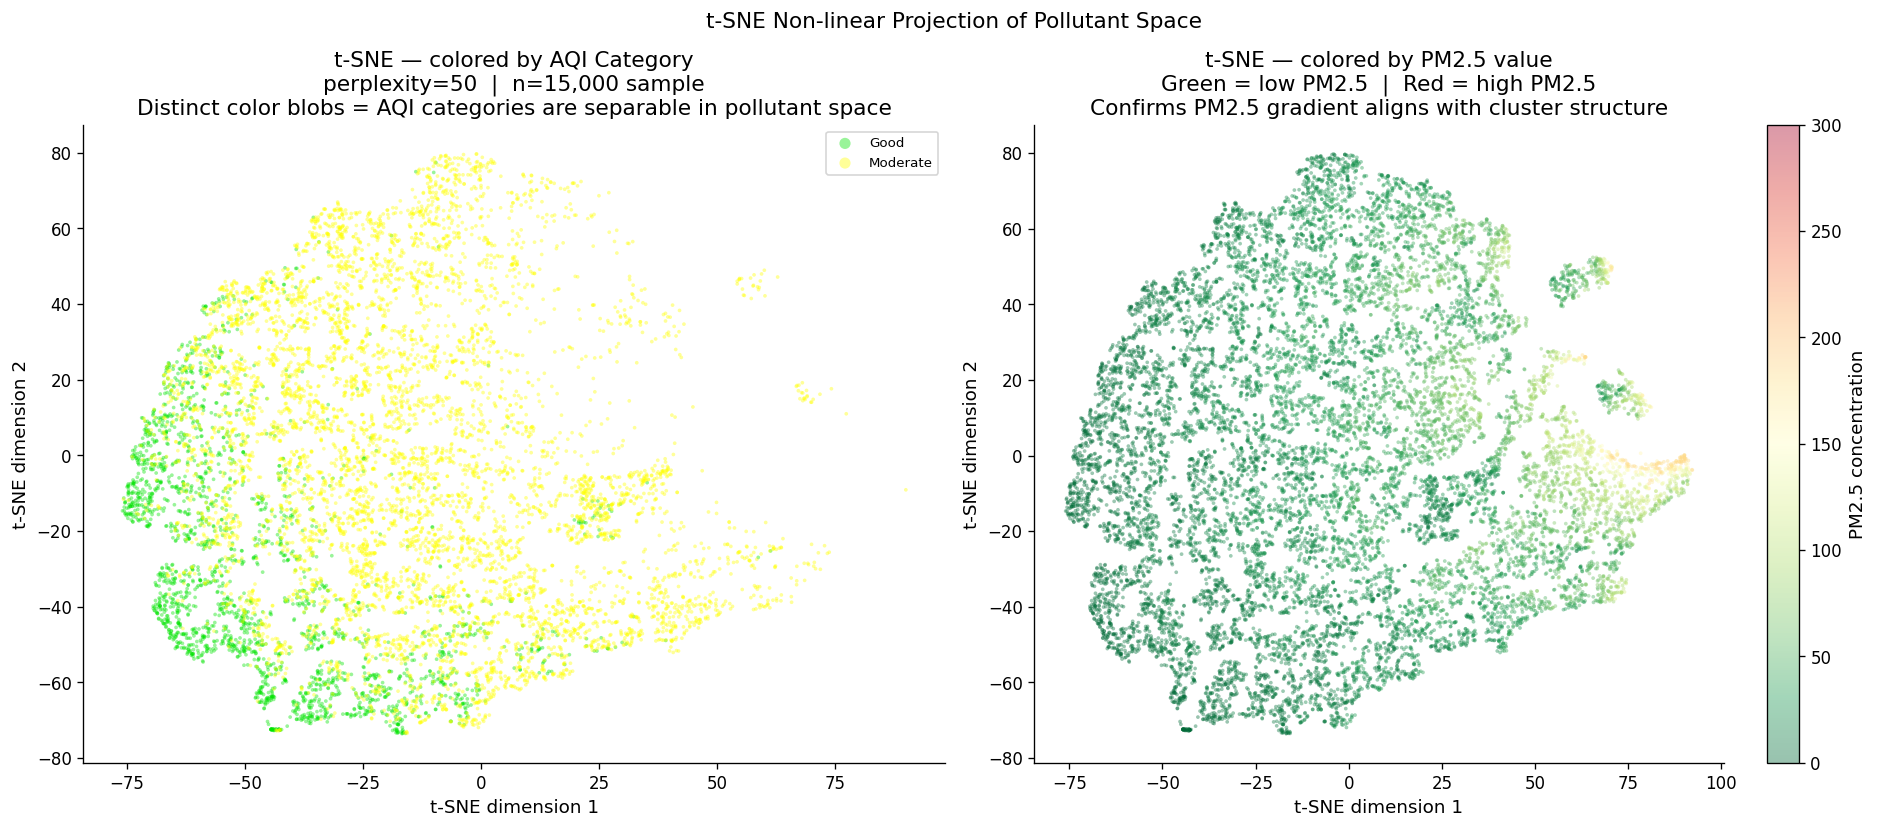

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colored by AQI category
if cat_col and cat_col in df_dim.columns:
    tsne_cats  = df_dim[cat_col].iloc[tsne_idx].astype(str).str.strip().str.title().values
    tsne_colors = [CAT_COLORS.get(c, '#888888') for c in tsne_cats]

    for cat in CAT_ORDER:
        mask = tsne_cats == cat
        if mask.sum() > 0:
            axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                            c=CAT_COLORS.get(cat, '#888'),
                            label=cat, alpha=0.4, s=5,
                            edgecolors='none')
    axes[0].legend(fontsize=8, markerscale=3)
else:
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.3, s=4, color='#42A5F5')

axes[0].set_title(f't-SNE — colored by AQI Category\n'
                  f'perplexity=50  |  n={tsne_n:,} sample\n'
                  f'Distinct color blobs = AQI categories are separable in pollutant space')
axes[0].set_xlabel('t-SNE dimension 1')
axes[0].set_ylabel('t-SNE dimension 2')

# Right: colored by PM2.5 value
pm25_col = next((c for c in pollutant_cols if 'pm2' in c.lower() and 'pm10' not in c.lower()), None)
if pm25_col:
    pm25_vals = df_dim[pm25_col].iloc[tsne_idx].values
    sc = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                         c=pm25_vals, cmap='RdYlGn_r',
                         vmin=0, vmax=300,
                         alpha=0.4, s=5, edgecolors='none')
    plt.colorbar(sc, ax=axes[1], label='PM2.5 concentration')
else:
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.3, s=4, color='#EF5350')

axes[1].set_title(f't-SNE — colored by PM2.5 value\n'
                  f'Green = low PM2.5  |  Red = high PM2.5\n'
                  f'Confirms PM2.5 gradient aligns with cluster structure')
axes[1].set_xlabel('t-SNE dimension 1')
axes[1].set_ylabel('t-SNE dimension 2')

plt.suptitle('t-SNE Non-linear Projection of Pollutant Space', fontsize=13)
plt.tight_layout()
plt.show()

Running t-SNE with 3 perplexity values for comparison...
(Using 5000-row sub-sample for speed)


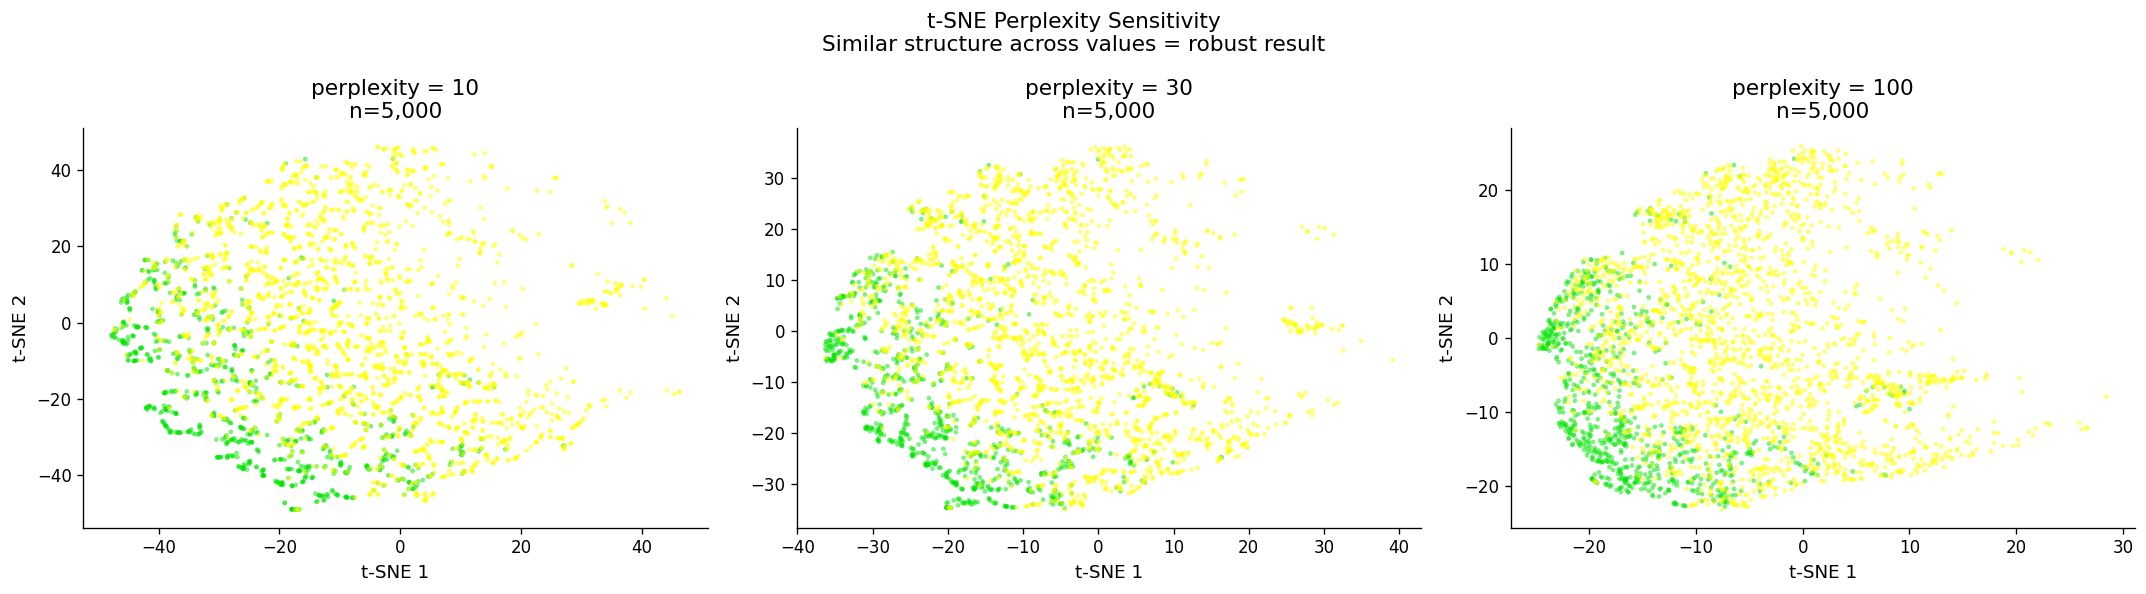

In [12]:
# ── Perplexity sensitivity — run t-SNE with 3 different perplexity values ──
print('Running t-SNE with 3 perplexity values for comparison...')
print('(Using 5000-row sub-sample for speed)')

perp_n   = min(5000, tsne_n)
perp_idx = np.random.RandomState(0).choice(tsne_n, perp_n, replace=False)
X_perp   = X_pre[perp_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [10, 30, 100]):
    t = TSNE(n_components=2, perplexity=perp, learning_rate='auto',
         init='pca', random_state=RANDOM_STATE, max_iter=500, verbose=0)
    Xt = t.fit_transform(X_perp)

    if cat_col and cat_col in df_dim.columns:
        cats_perp = df_dim[cat_col].iloc[tsne_idx[perp_idx]].astype(str).str.strip().str.title().values
        for cat in CAT_ORDER:
            mask = cats_perp == cat
            if mask.sum() > 0:
                ax.scatter(Xt[mask, 0], Xt[mask, 1],
                           c=CAT_COLORS.get(cat, '#888'),
                           label=cat, alpha=0.5, s=8, edgecolors='none')
    else:
        ax.scatter(Xt[:, 0], Xt[:, 1], alpha=0.4, s=6, color='#42A5F5')

    ax.set_title(f'perplexity = {perp}\nn={perp_n:,}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('t-SNE Perplexity Sensitivity\n'
             'Similar structure across values = robust result', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 7 — Save Dimensionality Datasets

In [13]:
# ── PCA output: all components ─────────────────────────────────────────────
pca_out = pd.DataFrame(
    X_pca_full,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
if city_col and city_col in df_dim.columns:
    pca_out.insert(0, city_col, df_dim[city_col].values)
if cat_col and cat_col in df_dim.columns:
    pca_out[cat_col] = df_dim[cat_col].values

# ── Scaled pollutant matrix ────────────────────────────────────────────────
scaled_out = pd.DataFrame(X_scaled, columns=pollutant_cols)
if city_col and city_col in df_dim.columns:
    scaled_out.insert(0, city_col, df_dim[city_col].values)
if cat_col and cat_col in df_dim.columns:
    scaled_out[cat_col] = df_dim[cat_col].values

# ── t-SNE sample output ────────────────────────────────────────────────────
tsne_out = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
if city_col and city_col in df_dim.columns:
    tsne_out.insert(0, city_col, df_dim[city_col].iloc[tsne_idx].values)
if cat_col and cat_col in df_dim.columns:
    tsne_out[cat_col] = df_dim[cat_col].iloc[tsne_idx].values
# Add original pollutant values for reference
for col in pollutant_cols:
    tsne_out[col] = df_dim[col].iloc[tsne_idx].values

# ── PCA loadings (for interpretation) ─────────────────────────────────────
loadings_out = loadings_df.copy()
loadings_out['explained_variance_pct'] = exp_var * 100

# Save paths
SCALED_PATH   = os.path.join(OUTPUT_DIR, 'pollutant_matrix_scaled.csv')
PCA_PATH      = os.path.join(OUTPUT_DIR, 'pca_components.csv')
LOADINGS_PATH = os.path.join(OUTPUT_DIR, 'pca_loadings.csv')
TSNE_PATH     = os.path.join(OUTPUT_DIR, 'tsne_sample.csv')

scaled_out.to_csv(SCALED_PATH,     index=False)
pca_out.to_csv(PCA_PATH,           index=False)
loadings_out.to_csv(LOADINGS_PATH, index=True)
tsne_out.to_csv(TSNE_PATH,         index=False)

print('SAVED:')
for path in [SCALED_PATH, PCA_PATH, LOADINGS_PATH, TSNE_PATH]:
    mb = os.path.getsize(path) / 1024**2
    print(f'  {os.path.basename(path):<40} {mb:.1f} MB')

print()
print('=' * 60)
print('  STEP 6 COMPLETE')
print('=' * 60)
print(f'  Rows in scaled matrix     : {len(X_scaled):,}')
print(f'  Pollutant features        : {pollutant_cols}')
print(f'  PCA components            : {n_components}')
print(f'  Variance in PC1+PC2       : {(ev2[0]+ev2[1])*100:.1f}%')
print(f'  Components for 90% var    : {n_for_90}')
print(f'  SVD effective rank        : {eff_rank}')
print(f'  t-SNE sample size         : {tsne_n:,}')
print()
print('  TO USE PCA IN A MODEL:')
print('  from sklearn.decomposition import PCA')
print('  X = pd.read_csv("data/cleaned/04_dimensionality/pollutant_matrix_scaled.csv")')
print(f'  pca = PCA(n_components={n_for_90}).fit_transform(X[pollutant_cols])')
print('=' * 60)

SAVED:
  pollutant_matrix_scaled.csv              107.0 MB
  pca_components.csv                       107.7 MB
  pca_loadings.csv                         0.0 MB
  tsne_sample.csv                          0.9 MB

  STEP 6 COMPLETE
  Rows in scaled matrix     : 842,160
  Pollutant features        : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
  PCA components            : 6
  Variance in PC1+PC2       : 80.5%
  Components for 90% var    : 4
  SVD effective rank        : 4
  t-SNE sample size         : 15,000

  TO USE PCA IN A MODEL:
  from sklearn.decomposition import PCA
  X = pd.read_csv("data/cleaned/04_dimensionality/pollutant_matrix_scaled.csv")
  pca = PCA(n_components=4).fit_transform(X[pollutant_cols])
